**Objetivo**: Implementar e avaliar a arquitetura PointNet para classificação de nuvens de pontos 3D no dataset ModelNet40. \
**Artigo de referência**: [PointNet: Deep Learning on Point Sets for 3D Classification and Segmentation](https://arxiv.org/pdf/1612.00593)

## Dataset

O dataset utilizado é o **ModelNet40**, que contém 12.311 modelos CAD de 40 categorias diferentes.

## Arquitetura PointNet

Treinamos e avaliamos duas arquiteturas diferentes:
- Pointnet básica (sem Transform net)
- Pointnet (com Transformet net - conforme artigo)

O artigo original aplica uma Transform Net, uma rede que aprende uma matrix. Essa rede é aplicada em dois momentos: 
- No input, essa rede é usada para transformar os pontos originais, de forma a deixar a rede mais mais robusta a rotações e pequena mudanças de pose. 
- Depois da primeira camada de features, aprende-se um alinhamento no espaço das características.

Arquitetura:

```text
Input Point Cloud
(B, N, 3)
      │
      ▼
Input Transform Net (apenas na segunda versão)
(T-Net 3×3)
      │
      ▼
Aligned Point Cloud (apenas na segunda versão)
(B, N, 3)
      │
      ▼
Transpose
(B, 3, N)
      │
      ▼
Conv1D(3 → 64) + BatchNorm + ReLU
      │
      ▼
Conv1D(64 → 64) + BatchNorm + ReLU
      │
      ▼
Feature Transform Net (apenas na segunda versão)
(T-Net 64×64)
      │
      ▼
Transformed Features (apenas na segunda versão)
(B, 64, N)
      │
      ▼
Conv1D(64 → 64) + BatchNorm + ReLU
      │
      ▼
Conv1D(64 → 128) + BatchNorm + ReLU
      │
      ▼
Conv1D(128 → 1024) + BatchNorm + ReLU
      │
      ▼
Global Max Pooling
      │
      ▼
Global Feature Vector (1024)
      │
      ▼
FC(1024 → 512) + BatchNorm + ReLU
      │
      ▼
FC(512 → 256) + BatchNorm + ReLU
      │
      ▼
Dropout(p = 0.3)
      │
      ▼
FC(256 → 40)
      │
      ▼
Class Scores
(B, 40)
```

## Configurações de treinamento

As configurações de treinamento foram todas retiradas do paper e são as mesmas para as 2 arquiteturas apresentadas.

In [1]:
import json
import pandas as pd

with open("configs/pointnet.json", "r") as f:
    config = json.load(f)

config.pop("model", None)

df = pd.DataFrame(
    list(config.items()),
    columns=["Hiperparâmetro", "Valor"]
)

df

,Hiperparâmetro,Valor
0,seed,42
1,gpu,0
2,log_dir,log
3,num_point,1024
4,max_epoch,250
5,batch_size,32
6,learning_rate,0.001
7,momentum,0.9
8,optimizer,adam
9,decay_step,200000


## Curvas de treinamento

In [2]:
%run train.py --config pointnet_basic

**** EPOCH 000 ****
----0-----
mean loss: 2.439651
accuracy: 0.374512
----1-----
mean loss: 1.609360
accuracy: 0.550245
----2-----
mean loss: 1.359194
accuracy: 0.618652
----3-----
mean loss: 1.201583
accuracy: 0.652832
----4-----
mean loss: 1.086245
accuracy: 0.682617
----0-----
----1-----
eval mean loss: 1.168829
eval accuracy: 0.662338
eval avg class acc: 0.589514
Model saved in file: log/20260605_161446/model.pth
**** EPOCH 001 ****
----0-----
mean loss: 1.002354
accuracy: 0.706543
----1-----
mean loss: 0.981086
accuracy: 0.696289
----2-----
mean loss: 0.922876
accuracy: 0.715074
----3-----
mean loss: 0.868020
accuracy: 0.750488
----4-----
mean loss: 0.918347
accuracy: 0.731445
----0-----
----1-----
eval mean loss: 0.869475
eval accuracy: 0.735795
eval avg class acc: 0.680939
**** EPOCH 002 ****
----0-----
mean loss: 0.822769
accuracy: 0.747559
----1-----
mean loss: 0.850264
accuracy: 0.736816
----2-----
mean loss: 0.816073
accuracy: 0.751953
----3-----
mean loss: 0.775007
accuracy

In [3]:
%run train.py --config pointnet

**** EPOCH 000 ****
----0-----
mean loss: 3.293459
accuracy: 0.227539
----1-----
mean loss: 2.587199
accuracy: 0.332721
----2-----
mean loss: 2.281877
accuracy: 0.376465
----3-----
mean loss: 2.002322
accuracy: 0.433594
----4-----
mean loss: 1.827139
accuracy: 0.484375
----0-----
----1-----
eval mean loss: 1.893306
eval accuracy: 0.454951
eval avg class acc: 0.354143
Model saved in file: log/20260605_163309/model.pth
**** EPOCH 001 ****
----0-----
mean loss: 1.696839
accuracy: 0.520020
----1-----
mean loss: 1.618874
accuracy: 0.544922
----2-----
mean loss: 1.475991
accuracy: 0.564951
----3-----
mean loss: 1.358944
accuracy: 0.608887
----4-----
mean loss: 1.416634
accuracy: 0.580078
----0-----
----1-----
eval mean loss: 1.354606
eval accuracy: 0.593750
eval avg class acc: 0.503911
**** EPOCH 002 ****
----0-----
mean loss: 1.304815
accuracy: 0.611328
----1-----
mean loss: 1.270595
accuracy: 0.628906
----2-----
mean loss: 1.235203
accuracy: 0.629883
----3-----
mean loss: 1.145584
accuracy

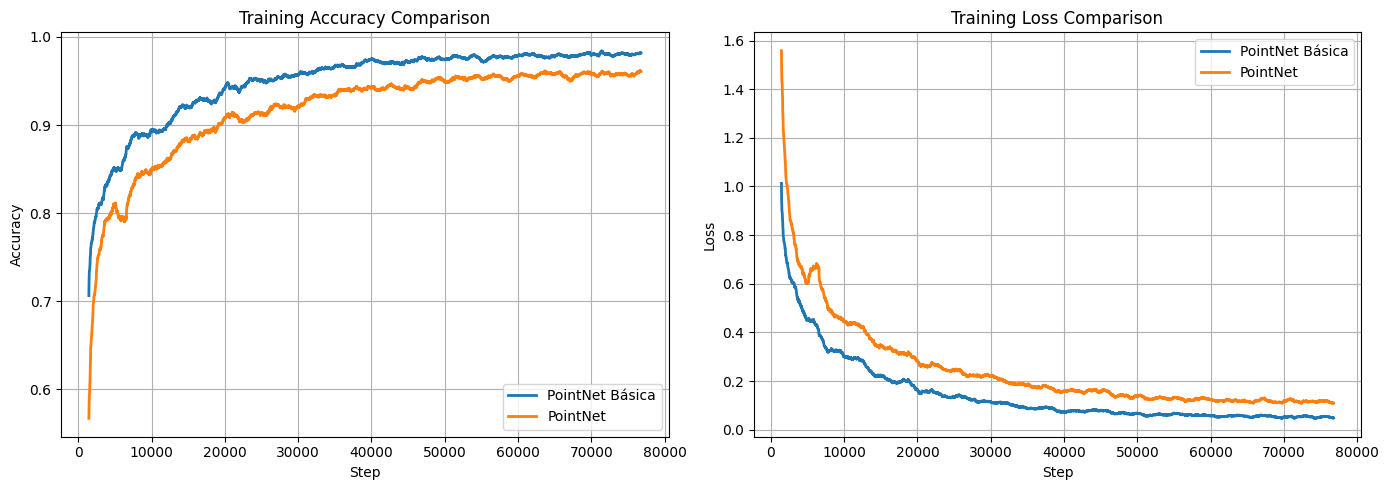

In [4]:
from tensorboard.backend.event_processing import event_accumulator
import matplotlib.pyplot as plt
import numpy as np

runs = [
    "log/20260605_161446/train",
    "log/20260605_163309/train",
]

model_names = [
    "PointNet Básica",
    "PointNet"
]

window = 200

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for run, model_name in zip(runs, model_names):
    ea = event_accumulator.EventAccumulator(run)
    ea.Reload()

    acc_events = ea.Scalars("accuracy")

    steps = np.array([e.step for e in acc_events])
    accs = np.array([e.value for e in acc_events])

    smooth_accs = np.convolve(
        accs,
        np.ones(window) / window,
        mode="valid"
    )

    smooth_steps = steps[window - 1:]

    axes[0].plot(
        smooth_steps,
        smooth_accs,
        label=model_name,
        linewidth=2
    )

axes[0].set_title("Training Accuracy Comparison")
axes[0].set_xlabel("Step")
axes[0].set_ylabel("Accuracy")
axes[0].grid(True)
axes[0].legend()

for run, model_name in zip(runs, model_names):
    ea = event_accumulator.EventAccumulator(run)
    ea.Reload()

    loss_events = ea.Scalars("loss")

    steps = np.array([e.step for e in loss_events])
    losses = np.array([e.value for e in loss_events])

    smooth_losses = np.convolve(
        losses,
        np.ones(window) / window,
        mode="valid"
    )

    smooth_steps = steps[window - 1:]

    axes[1].plot(
        smooth_steps,
        smooth_losses,
        label=model_name,
        linewidth=2
    )

axes[1].set_title("Training Loss Comparison")
axes[1].set_xlabel("Step")
axes[1].set_ylabel("Loss")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

## Avaliação quantitativa

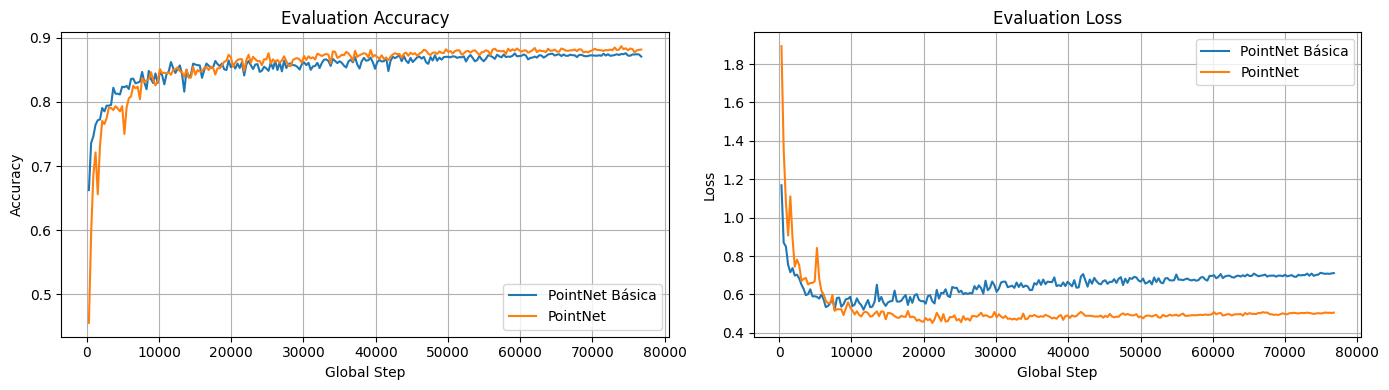

In [9]:
from tensorboard.backend.event_processing import event_accumulator
import matplotlib.pyplot as plt

runs = [
    "log/20260605_161446/test",
    "log/20260605_163309/test",
]

model_names = [
    "PointNet Básica",
    "PointNet"
]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for run, model_name in zip(runs, model_names):
    ea = event_accumulator.EventAccumulator(run)
    ea.Reload()

    events = ea.Scalars("eval/accuracy")

    steps = [e.step for e in events]
    values = [e.value for e in events]

    axes[0].plot(steps, values, label=model_name)

axes[0].set_title("Evaluation Accuracy")
axes[0].set_xlabel("Global Step")
axes[0].set_ylabel("Accuracy")
axes[0].grid(True)
axes[0].legend()

for run, model_name in zip(runs, model_names):
    ea = event_accumulator.EventAccumulator(run)
    ea.Reload()

    events = ea.Scalars("eval/loss")

    steps = [e.step for e in events]
    values = [e.value for e in events]

    axes[1].plot(steps, values, label=model_name)

axes[1].set_title("Evaluation Loss")
axes[1].set_xlabel("Global Step")
axes[1].set_ylabel("Loss")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

In [17]:
%run evaluation/evaluate.py --config pointnet_basic --run 20260605_161446
%run evaluation/evaluate.py --config pointnet --run 20260605_163309

In [19]:
import json
import pandas as pd
from pathlib import Path

evaluation_dir = Path("evaluation")

rows = []

for config_dir in evaluation_dir.iterdir():

    results_file = config_dir / "results.json"

    if not results_file.exists():
        continue

    with open(results_file) as f:
        results = json.load(f)

    rows.append({
        "Model": results["model_name"],
        "Accuracy": results["eval_accuracy"],
        "Avg Class Accuracy": results["eval_avg_class_accuracy"],
        "Loss": results["eval_loss"],
    })

df = pd.DataFrame(rows)

order = {
    "pointnet_basic": 0,
    "pointnet": 1
}

df["order"] = df["Model"].map(order)

df = (
    df
    .sort_values("order")
    .drop(columns="order")
    .reset_index(drop=True)
)

df

,Model,Accuracy,Avg Class Accuracy,Loss
0,pointnet_basic,0.875000,0.846764,0.696761
1,pointnet,0.887175,0.853524,0.498443


A segunda versão da Pointnet se mostrou melhor nas métricas de avaliação. É a versão a final escolhida.

## Exemplos de classificação do melhor modelo

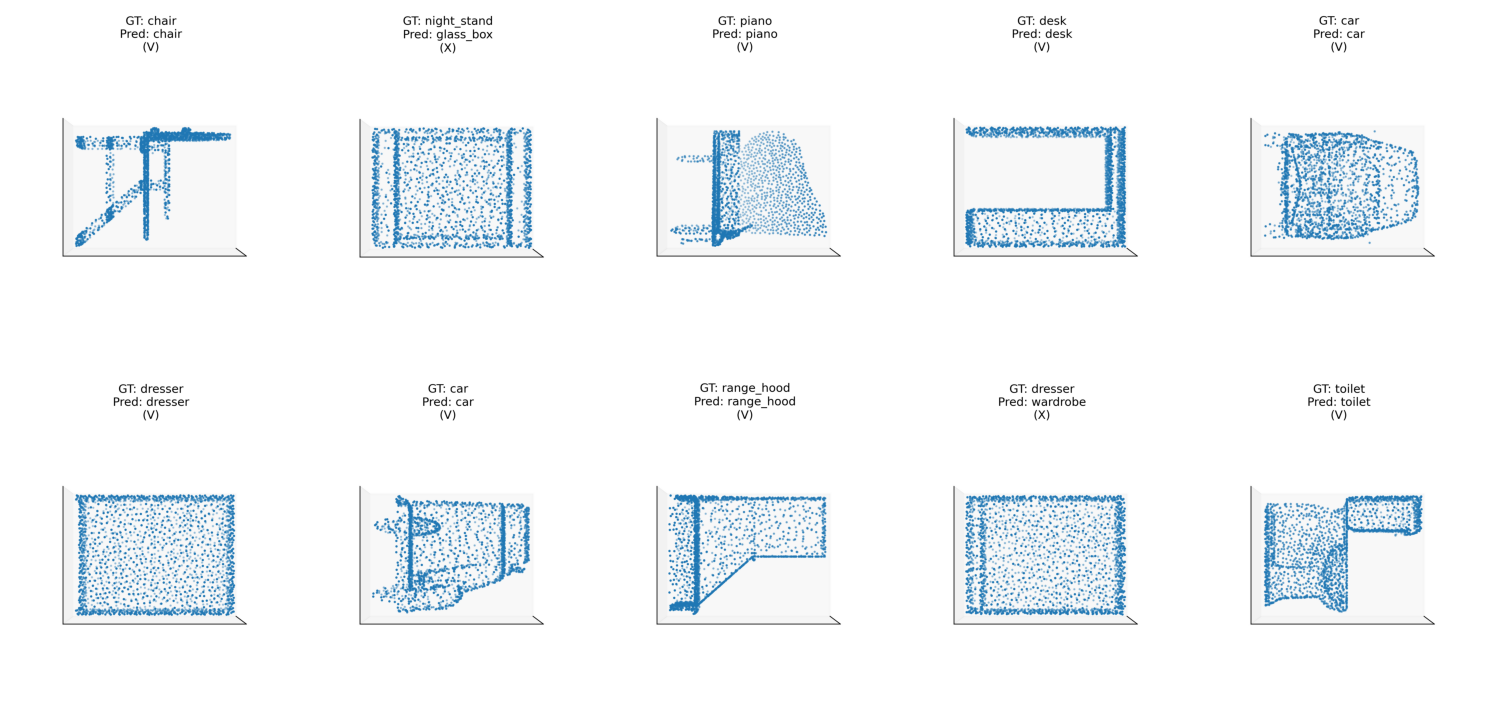

In [21]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

image_dir = Path("evaluation/20260605_163309/test_examples")

image_files = sorted(image_dir.glob("example_*.png"))

fig, axes = plt.subplots(2, 5, figsize=(15, 8))

for ax, image_file in zip(axes.flatten(), image_files):
    img = Image.open(image_file)

    ax.imshow(img)
    ax.axis("off")

plt.tight_layout()
plt.show()

## Discussão final

A PointNet obteve resultados satisfatórios, atingindo métricas de acurácia próximas às do artigo original. \
Como próximo passo, adaptaremos o vetor de features gerado pela PointNet para a arquitetura PCN, que será utilizada na tarefa principal de completação de nuvens de pontos 3D.